# Week-3 Day-5 (this file is not part of the submission sir, please just ignore it, uI still pushed it to the repo just so its secure for later learning)

---


# Week 3 – Friday Hackathon

---

## Goal

- Design and implement a reusable Analytics Layer on top of a large enterprise database and give us a analytical dashboard on notebook like you did previously in your assignments. Instead of writing isolated SQL queries, build a complete SQL pipeline that transforms raw operational data into business-ready datasets.

---

## Scenario

- The current database is optimized for daily transactions but is difficult to use for business reporting.
- Your task is to design an analytics pipeline that transforms raw operational data into reusable analytical datasets and produces executive-level dashboard insights.
The final solution should support future dashboards and reporting without repeatedly querying the raw operational tables.

---

## Dataset

- Dataset is given in attached zip file

---

## Hackathon Requirements

### Task 1 — Design an Analytics Layer
- The operational database should not be queried repeatedly.
- Design an intermediate analytics layer by creating reusable analytical tables or views.
- Examples include (these are only examples, not mandatory names):

      - Customer Analytics.
      - Product Analytics.
      - Sales Analytics.
      - Employee Analytics.
      - Inventory Analytics.
      - Territory Analytics.
      - Vendor Analytics.
      - Purchasing Analytics.
      - Date Analytics.
      - Executive KPI Analytics.


- Requirements

      - Use data from at least five different business domains..
      - Create at least 10 reusable analytical tables or views..
      - Every analytical table should build upon previous tables whenever possible..
      - Avoid recalculating the same metrics multiple times..

---

### Task 2 — Build a Chained SQL Pipeline
- Your SQL solution should form a dependency chain rather than isolated queries.

- Example flow:

- Raw Tables
- ↓
- Analytics Tables
- ↓
- Business Metrics
- ↓
- Customer Segmentation
- ↓
- Regional Analysis
- ↓
- Executive KPI Tables
- ↓
- Python Visualizations


- Each stage must reuse outputs created in previous stages.

---

### Task 3 — Executive KPI Datasets
- Using your analytics layer, create dashboard-ready datasets for:
**Sales**

- Monthly Revenue
- Quarterly Revenue
- Sales Growth
- Best Selling Products
- Lowest Performing Products.

- **Customers**

- Customer Segments.
- Customer Lifetime Value.
- Repeat Customers.
- Customer Retention.

- **Products**

• Product Profitability.
• Category Performance.
• Product Rankings.

- **Employees**

• Salesperson Rankings.
• Revenue Contribution.
• Performance Comparison.

- **Territories**

- Regional Revenue.
- Regional Growth.
- Top Territories.
- Lowest Performing Territories.

- **Inventory / Purchasing**

- Inventory Health.
- Products with Low Stock.
- Supplier Performance.
- Purchasing Trends.

---

### Task 4 — Advanced SQL Requirements
- Your solution should demonstrate advanced SQL concepts.
- **Your complete project must include:**

- Multiple chained CTEs.
- Window Functions.
- CASE WHEN.
- Conditional Aggregation.
- Ranking Functions.
- Complex JOINs.
- Reusable intermediate tables/views.

- The focus is on writing maintainable analytical SQL rather than isolated queries.

---

### Task 5 — Python Analytics Notebook

- Using Jupyter Notebook (This is where you will use your previously attained skills):

- 1-Connect to PostgreSQL from Jupyter Notebook.
- 2-Use pandas.read_sql() to read only the final analytical tables/views created in your SQL pipeline (avoid querying raw tables in the notebook).
- 3-Generate visualizations from these analytical datasets
- 4-Provide business insights below each chart.

- **Create at least 8 visualizations, such as:**

- Revenue Trend.
- Sales by Territory.
- Customer Segments.
- Product Performance.
- Category Revenue.
- Employee Performance.
- Inventory Status.
- Executive KPI Summary.


- Each chart must include a short explanation of what the business can learn from it.

---

### Task 6 — Executive Recommendations

- Based on your analysis, prepare recommendations for management.

Include:

- Five business opportunities.
- Five business risks.
- Five actionable recommendations.


- Every recommendation must be supported by your SQL analysis and visualizations.

---

### Bonus Challenge

- Design your SQL project so that adding a new dashboard in the future requires only reading from your analytical tables—not from the raw tables.

- Think like an Analytics Engineer building a reusable reporting layer.

---

## Deliverables

- Submit the following:

1. **analytics_pipeline.sql**

- All SQL scripts.
- Well commented.
- Organized into logical stages.

2. **executive_analysis.ipynb**

- **Notebook containing:**

- PostgreSQL connection.
- SQL execution using Pandas.
- Visualizations.
- Business insights.
- Executive recommendations.

3. **README.md**

- Include:

- Database overview.
- Analytics architecture.
- Intermediate tables created.
- SQL design decisions.
- Challenges faced.
- Assumptions made.

4. **Project Structure**

- enterprise_analytics_hackathon/

      │
      ├── README.md
      │
      ├── analytics_pipeline.sql
      │
      ├── executive_analysis.ipynb
      │
      ├── screenshots/
      │
      ├── charts/
      │
      └── documentation/


---

---
---

---

# Understanding the Database

- The database is on a fictional company called AdventureWorks. It is supposed to be a company that sells bikes and bike-related products
- **68 total base tables**
- These 68 tables are divided into 5 total schemas:
  - humanresources (6 tables)
  - person (13 tables)
  - production (25)
  - purchasing (5)
  - sales (19)
  - So another new concept in day 5 is "schemas" inside a database, cool. so before I used to think db->tables->columns but now its db->schemas->tables->columns.
  - although, a schema can contain more than just tables I think, the object explorer shows other stuff like views and functions etc
- The db also has more schemas like hr, pe, pr, pu which are schemas for convienience, they have views in them. I will probably be ignoring all those shorthand ones, ganna do it the normal way for the sake of understanding.
- the zip file mam sent has 2 .sql files, install.sql for postgres I think and instawdb.sql for sql server, no need to care about instawdb i guess

# Mapping out important relationships for the tasks

- I am ganna ask codex to map out the important relationships, the db as a whole is too insane, it has 68 total tables and 66 fricking FK relationships

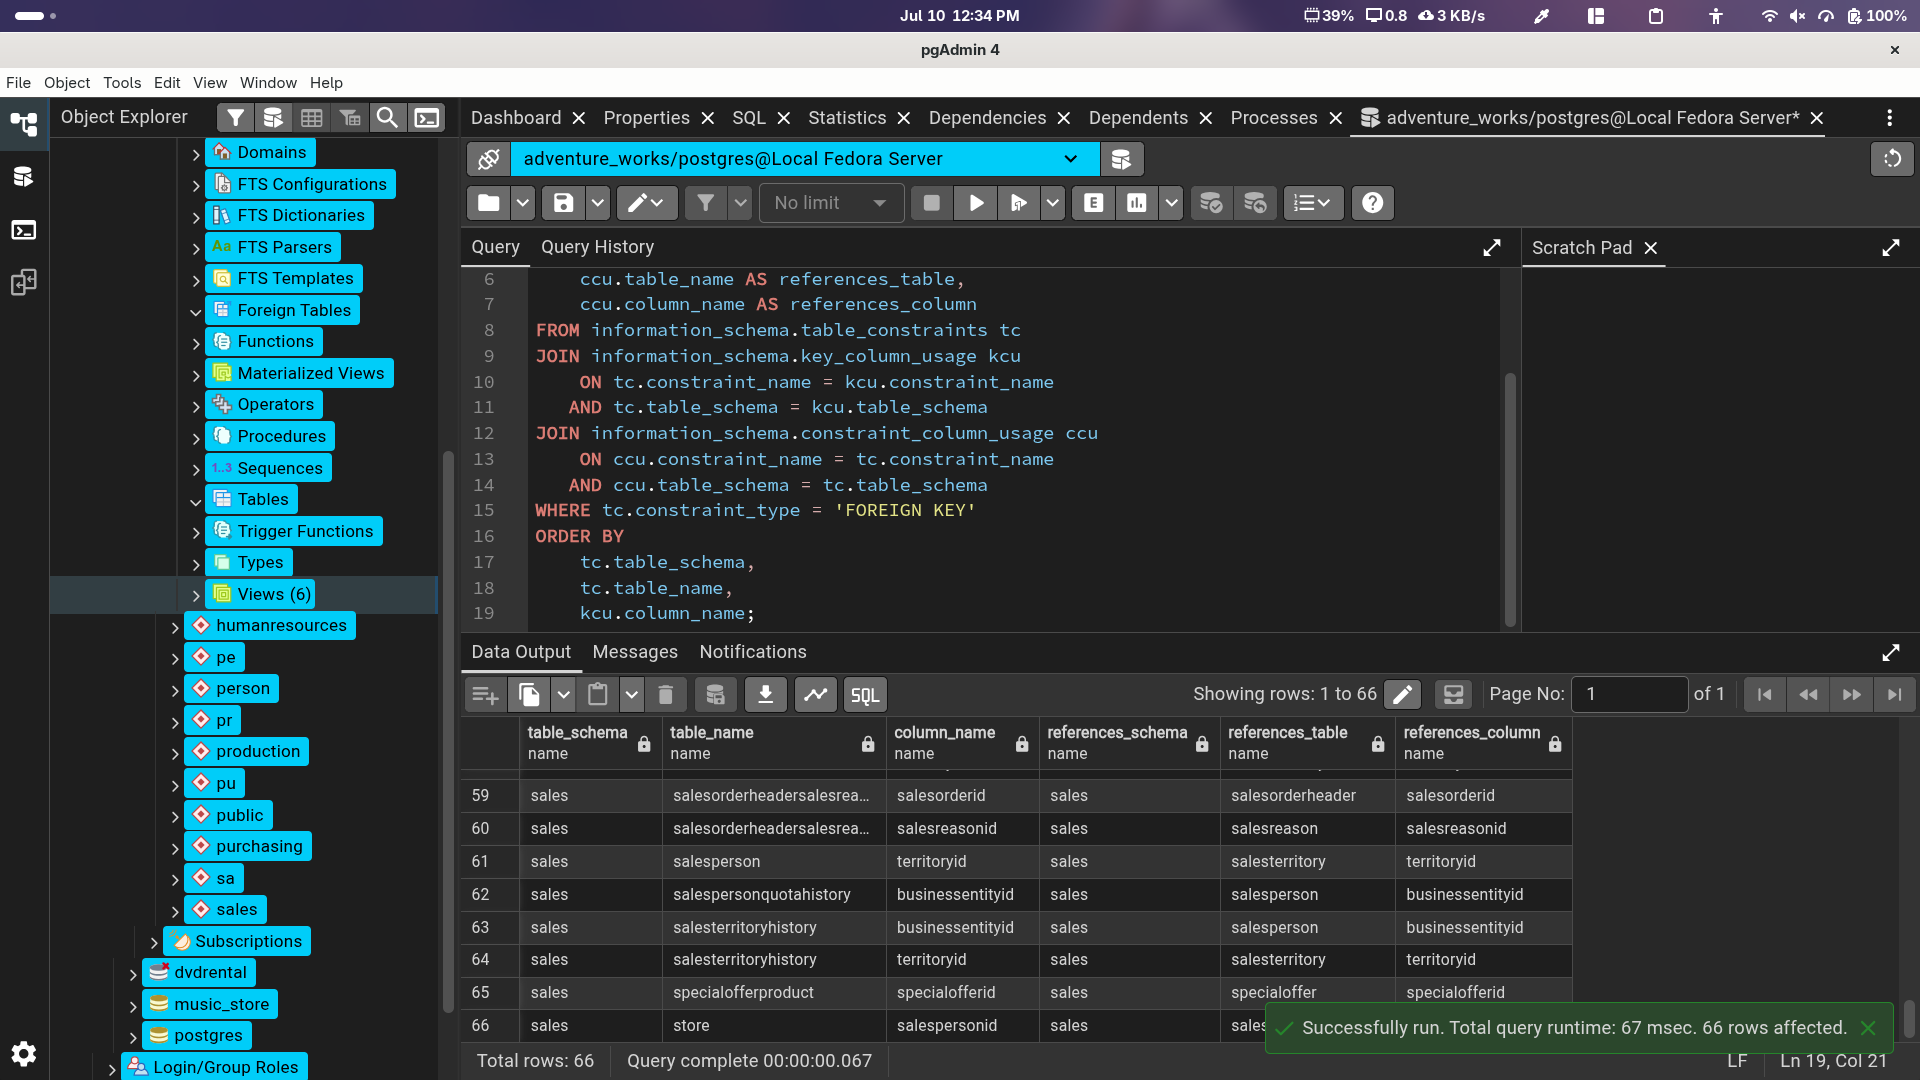

- I will go insane reading every last one, so lets get codex to map out the important ones that I will use in the tasks
  - Sales Order Header stores one row per order, then in that order, the customer could have ordered several things, so we link Sales Order Header to Sales Order Detail, which stores one row per product inside an order. th SOD will tell the quantity of the product ordered and the unitprice and unitpricediscount etc. so Sales Order Header + Sales Order Details will answer a lot of the sales related questions
  - will just do the rest in pgadmin

# New Concepts
- This assignment doesn't have any learning resources weirdly so ganna have to learn on my own, the first obvious new concept is views, didn't cover this properly in the previous 4 tasks

## Views

- Here is the syntax

```sql
CREATE VIEW analytics.monthly_sales AS
SELECT
    DATE_TRUNC('month', orderdate) AS month,
    SUM(totaldue) AS revenue
FROM sales.salesorderheader
GROUP BY 1;

-- after the creation of the view, just gotta do this

SELECT *
FROM analytics.monthly_sales;
```